## SalaryScope – Salary Prediction Using Machine Learning

### Project Overview

Salary estimation plays a crucial role in decision-making for both job seekers and organizations. Understanding how factors such as education level, years of experience, job role, and geographic location influence salary can help individuals plan their careers and assist organizations in designing fair compensation structures.

The SalaryScope project focuses on building a machine learning–based salary prediction system using real-world employment data. The objective of this project is to analyze historical salary information and develop predictive models that estimate salary based on multiple professional and demographic attributes.

The project involves systematic data exploration, preprocessing, feature engineering, and model training using supervised learning techniques. Multiple regression models are implemented and evaluated to compare their performance and understand how different algorithms capture relationships between input features and salary outcomes.

This project emphasizes correct machine learning practices, including proper train–test splitting, data encoding, normalization, and performance evaluation. The insights obtained from this analysis can be useful for understanding salary trends and supporting data-driven decision-making in recruitment and career planning.


### Problem Statement

Salary determination is influenced by multiple factors such as education level, years of experience, job role, and geographic location. However, understanding how these factors collectively impact salary is not always straightforward, especially when dealing with large and diverse datasets.

The problem addressed in this project is to develop a reliable machine learning model that can predict an individual’s salary based on relevant professional and demographic attributes. By analyzing historical salary data, the project aims to identify key patterns and relationships among features and use them to estimate salary accurately.

The challenge involves handling both numerical and categorical data, performing appropriate preprocessing, and selecting suitable regression models that generalize well to unseen data.


### Project Objectives

The primary objectives of the SalaryScope project are as follows:

- To analyze and understand the impact of professional and demographic factors such as education level, years of experience, job role, and country on salary.
- To perform exploratory data analysis (EDA) to identify patterns, trends, and relationships within the salary dataset.
- To preprocess the dataset by handling missing values, encoding categorical variables, and applying appropriate feature scaling techniques.
- To build and evaluate multiple machine learning regression models for salary prediction.
- To compare the performance of different models using suitable evaluation metrics and identify the most effective approach.
- To derive meaningful insights from the analysis that can support data-driven decision-making related to career planning and compensation.


### Dataset Description

The dataset used in this project is titled **“Salary by Job Title and Country”** and is sourced from Kaggle. It contains salary information collected from various industries and regions worldwide and is made available under a **CC0: Public Domain license**, making it suitable for academic and analytical use.

The dataset consists of **6,680 records** and includes both numerical and categorical attributes related to an individual’s professional background. The target variable for this project is **Salary**, which is a numerical value representing annual compensation in US Dollars.

#### Dataset Features

- **Age**: Numerical feature representing the age of the employee.
- **Gender**: Categorical feature indicating the gender of the employee.
- **Education Level**: Numerical feature representing the highest level of education  
  (0: High School, 1: Bachelor’s Degree, 2: Master’s Degree, 3: PhD).
- **Job Title**: Categorical feature describing the employee’s job role.
- **Years of Experience**: Numerical feature indicating total professional experience in years.
- **Salary**: Numerical target variable representing annual salary in USD.
- **Country**: Categorical feature indicating the country of employment.
- **Race**: Categorical feature representing racial background.
- **Senior**: Binary feature indicating whether the employee holds a senior-level position.

This dataset was selected after reviewing multiple salary-related datasets to ensure relevance to the project objective, sufficient data volume, and the presence of meaningful features required for salary prediction and analysis.


## Data Inspection and Observation


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load the dataset
df = pd.read_csv("data/Salary.csv")

# Display first few rows
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Country,Race,Senior
0,32.0,Male,1,Software Engineer,5.0,90000.0,UK,White,0
1,28.0,Female,2,Data Analyst,3.0,65000.0,USA,Hispanic,0
2,45.0,Male,3,Manager,15.0,150000.0,Canada,White,1
3,36.0,Female,1,Sales Associate,7.0,60000.0,USA,Hispanic,0
4,52.0,Male,2,Director,20.0,200000.0,USA,Asian,0


In [2]:
# Check dataset structure and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5144 entries, 0 to 5143
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  5144 non-null   float64
 1   Gender               5144 non-null   object 
 2   Education Level      5144 non-null   int64  
 3   Job Title            5144 non-null   object 
 4   Years of Experience  5144 non-null   float64
 5   Salary               5144 non-null   float64
 6   Country              5144 non-null   object 
 7   Race                 5144 non-null   object 
 8   Senior               5144 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 361.8+ KB


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
# Summary statistics for numerical features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,5144.0,34.006610,7.762939,21.0,28.0,32.0,39.0,62.0
Education Level,5144.0,1.640941,0.882766,0.0,1.0,1.0,2.0,3.0
Years of Experience,5144.0,8.341660,6.233269,0.0,3.0,7.0,12.0,34.0
Salary,5144.0,114360.484642,52382.991760,25000.0,70000.0,114290.0,160000.0,250000.0
Senior,5144.0,0.160381,0.366995,0.0,0.0,0.0,0.0,1.0


In [5]:
# Check for missing values in each column
df.isnull().sum()


Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
Country                0
Race                   0
Senior                 0
dtype: int64

### Initial Data Inspection and Observations

An initial inspection was carried out to understand the structure and quality of the dataset. The dataset contains **6,680 records** with **9 features**, including a mix of numerical and categorical variables, making it suitable for regression-based analysis.

All columns were found to have **no missing values**, indicating that the dataset is complete and does not require any missing value treatment at this stage.

From the statistical summary, the average age of employees is around **33.6 years**, with ages ranging from **21 to 62 years**. The average years of experience is approximately **8.1 years**, showing a balanced representation of both early-career and experienced professionals.

The salary values vary widely, ranging from **\\$25,000 to \\$250,000**, with a median salary of about **$115,000**. This wide range suggests significant variation in compensation across different roles, experience levels, and job categories.

Overall, the dataset is clean, well-structured, and appropriate for further exploratory data analysis, preprocessing, and salary prediction using machine learning models.


## Exploratory Data Analysis (EDA)


### Salary Distribution (Histogram with KDE)


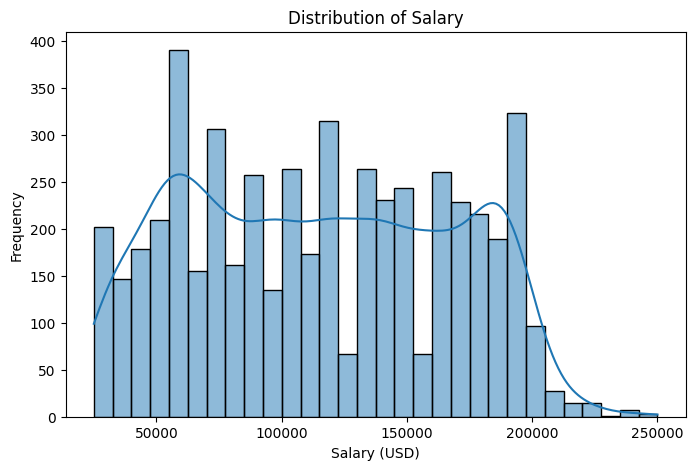

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Salary"], bins=30, kde=True)
plt.title("Distribution of Salary")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

# Save the figure
plt.savefig("plots/salary_distribution.png", bbox_inches="tight")

plt.show()


This histogram with kernel density estimation (KDE) illustrates the distribution of salaries in the dataset.

Most salary values fall between **\\$40,000  and \\$180,000**, indicating a wide but concentrated range of earnings. The distribution is **right-skewed**, with a smaller number of high-salary observations extending up to **$250,000**.

The presence of multiple peaks suggests different salary bands, likely influenced by job roles, experience levels, and seniority.


### Distribution of Age and Years of Experience


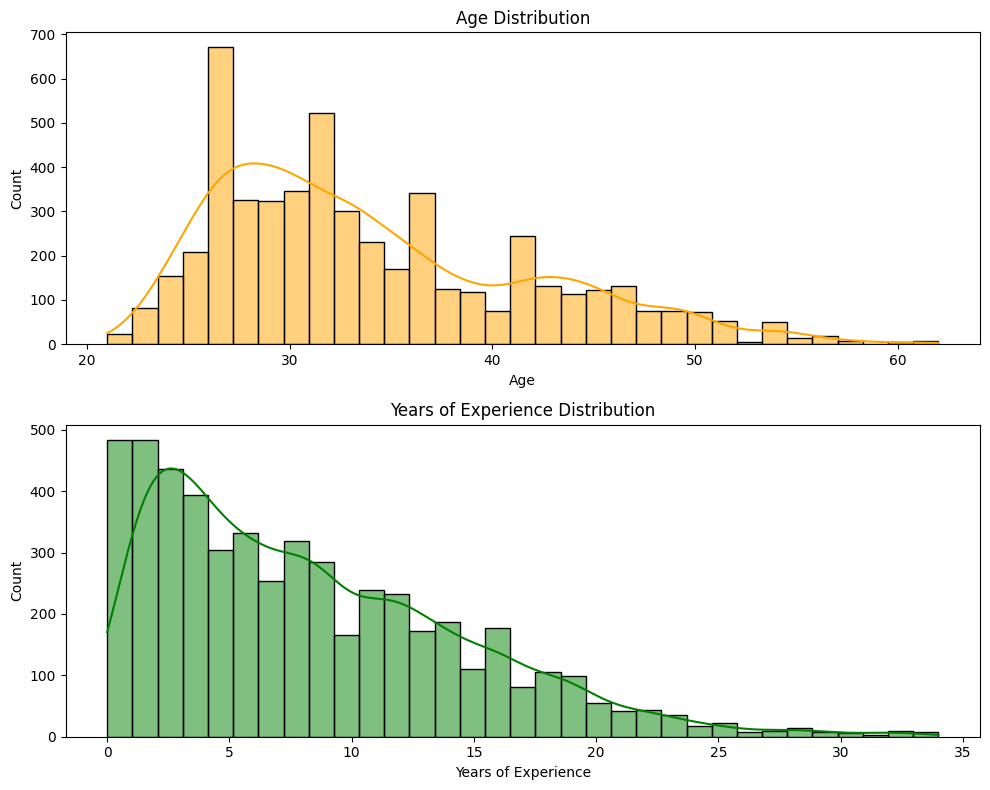

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

sns.histplot(df['Age'], kde=True, ax=ax[0], color='orange')
ax[0].set_title('Age Distribution')
ax[0].set_xlabel('Age')

sns.histplot(df['Years of Experience'], kde=True, ax=ax[1], color='green')
ax[1].set_title('Years of Experience Distribution')
ax[1].set_xlabel('Years of Experience')

plt.tight_layout()
plt.savefig("plots/age_experience_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


The age distribution shows that most employees fall within the 25–35 year range, indicating a workforce dominated by early to mid-career professionals. The distribution is slightly right-skewed, with fewer employees at higher age ranges.

The years of experience distribution is strongly right-skewed, with the majority of employees having fewer than 10 years of experience. This suggests that the dataset contains a larger proportion of junior and mid-level professionals, while highly experienced individuals are comparatively fewer.


### Salary Distribution by Education Level (Box Plot)


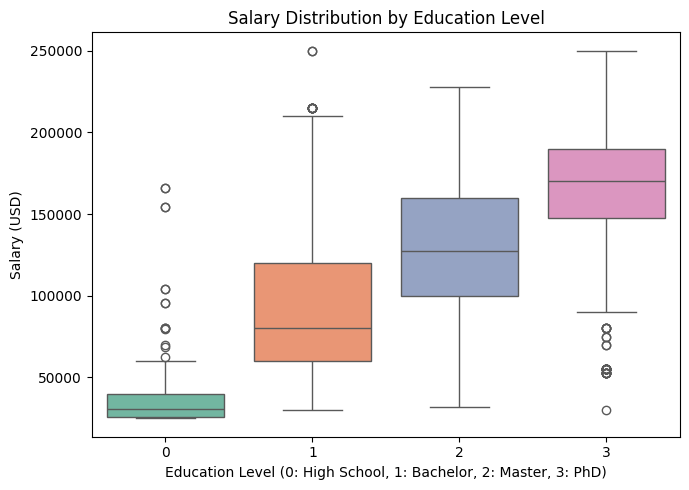

In [8]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Education Level",
    y="Salary",
    hue="Education Level",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Salary Distribution by Education Level")
plt.xlabel("Education Level (0: High School, 1: Bachelor, 2: Master, 3: PhD)")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_by_education_level.png", dpi=300)
plt.show()


The box plot shows how salaries vary across different education levels. A clear upward trend is observed, where higher education levels are associated with higher median salaries.

Employees with a High School education (Level 0) earn the lowest salaries with limited variation, while Bachelor’s and Master’s degree holders show a noticeable increase in both median salary and spread. PhD holders (Level 3) have the highest median salaries and wider variability, indicating the presence of both mid-range and high-paying roles.

Overall, the plot highlights education level as a strong factor influencing salary.


### Salary vs Years of Experience


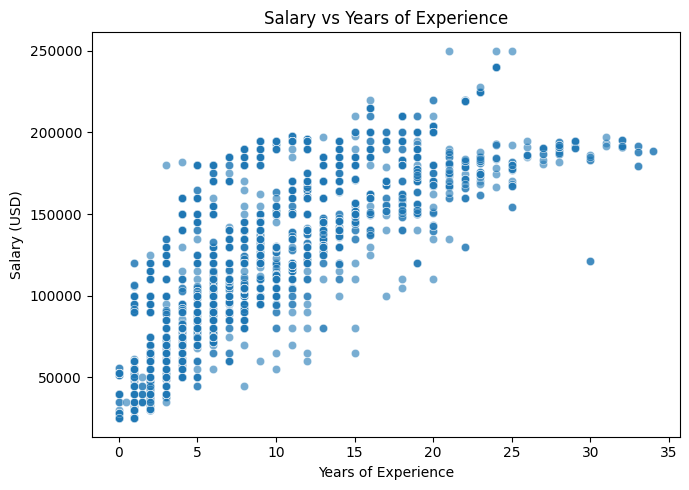

In [9]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x="Years of Experience",
    y="Salary",
    data=df,
    alpha=0.6
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_vs_experience.png", dpi=300)
plt.show()


This scatter plot shows the relationship between years of experience and salary. A clear positive trend is observed, where salary generally increases as years of experience increase. At lower experience levels, salaries are more tightly clustered, while at higher experience levels there is greater variation, indicating that factors beyond experience also influence salary at senior stages.


### Correlation Heatmap of Numerical Features


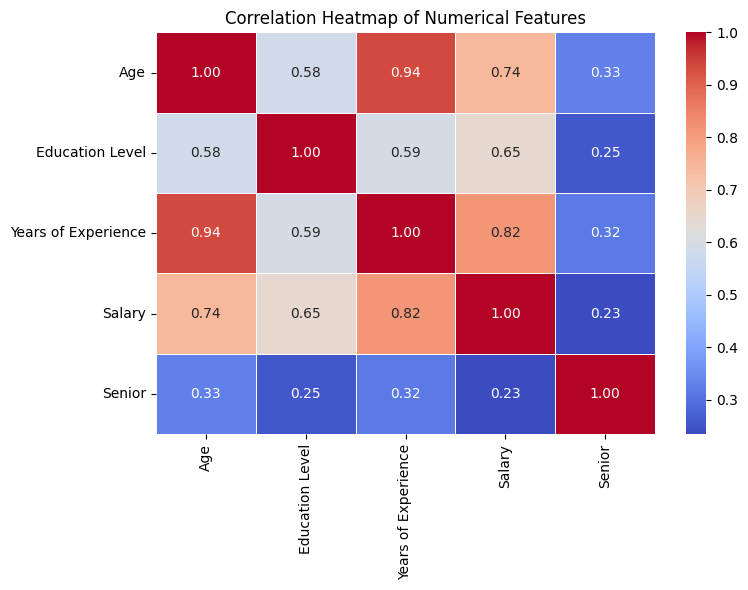

In [10]:
# Select only numerical features
numeric_cols = ["Age", "Education Level", "Years of Experience", "Salary", "Senior"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300)
plt.show()


The correlation heatmap shows the strength and direction of relationships between numerical variables. Salary has a strong positive correlation with Years of Experience (**0.81**), indicating that salaries tend to increase significantly with experience. Education Level also shows a moderate positive correlation with Salary (**0.65**), suggesting higher educational qualifications are generally associated with higher pay.

Age is positively correlated with Salary (**0.73**) and very strongly correlated with Years of Experience (**0.94**), which is expected as older individuals typically have more work experience. The Senior feature shows a weaker positive correlation with Salary (**0.22**), indicating that while senior roles tend to pay more, senior status alone is not the strongest determining factor.

Overall, Years of Experience emerges as the most influential numerical feature affecting salary, followed by Age and Education Level.


### Salary Distribution by Job Title


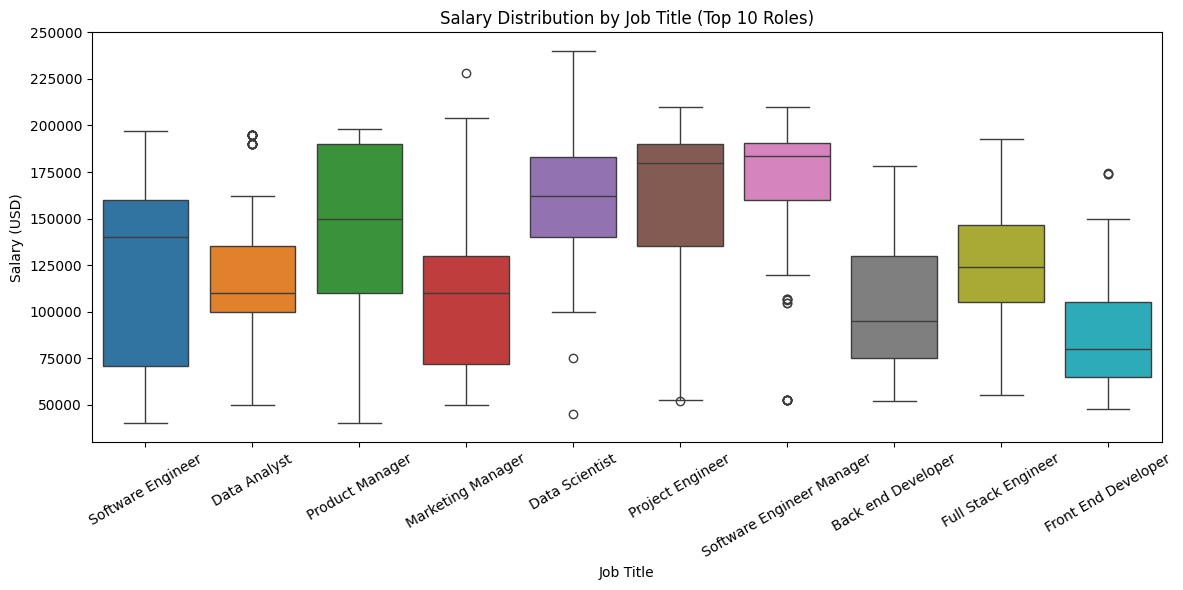

In [11]:
# Select top 10 most frequent job titles
top_jobs = df['Job Title'].value_counts().nlargest(10).index
df_top_jobs = df[df['Job Title'].isin(top_jobs)]

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Job Title',
    y='Salary',
    data=df_top_jobs,
    hue='Job Title',
    legend=False
)

plt.title('Salary Distribution by Job Title (Top 10 Roles)')
plt.xlabel('Job Title')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('plots/salary_by_job_title.png', dpi=300)
plt.show()


This boxplot compares salary distributions across the top 10 most common job titles. Noticeable differences in median salaries are observed among roles, with technical and managerial positions generally showing higher salary ranges. The spread and outliers within roles indicate variability due to factors such as experience, seniority, and location.


### Salary vs Age by Education Level

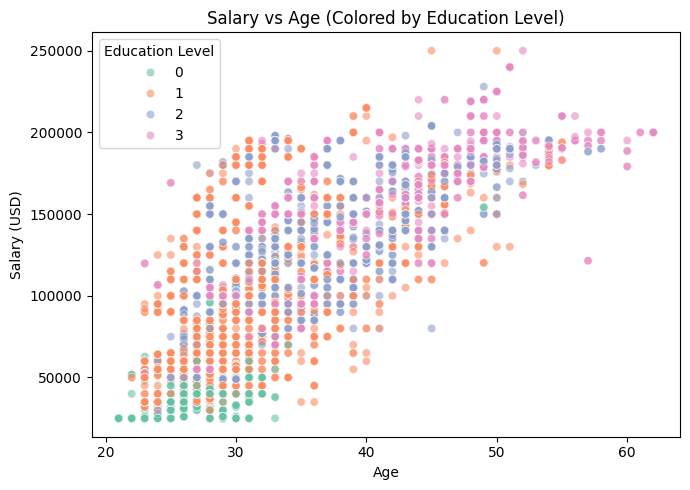

In [12]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x="Age",
    y="Salary",
    hue="Education Level",
    data=df,
    alpha=0.6,
    palette="Set2"
)

plt.title("Salary vs Age (Colored by Education Level)")
plt.xlabel("Age")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_vs_age.png", dpi=300)
plt.show()


This scatter plot illustrates the relationship between age and salary, with points colored by education level. A general upward trend is observed, indicating that salary tends to increase with age. However, significant overlap exists across education levels, showing that age alone does not determine compensation.

Employees with higher education levels (Master’s degree and PhD) are more frequently associated with higher salary ranges, especially at mid to later career stages. The spread of salaries at higher ages suggests that additional factors such as job role, experience, and seniority also play an important role in determining salary.

### Average Salary by Education Level and Gender

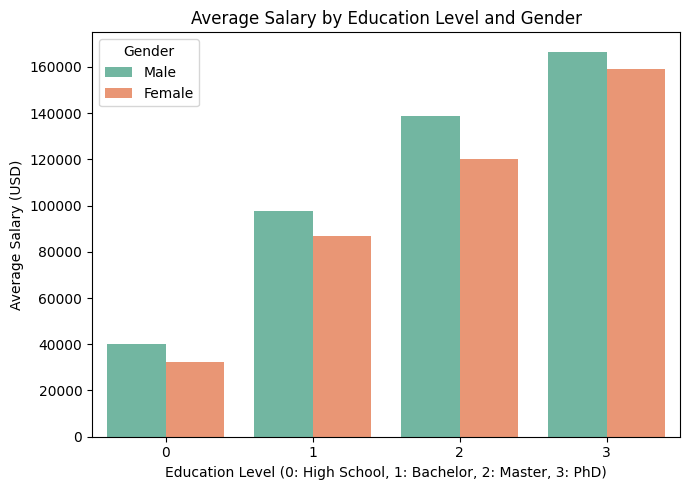

In [13]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x="Education Level",
    y="Salary",
    hue="Gender",
    data=df,
    estimator="mean",
    errorbar=None,
    palette="Set2"
)

plt.title("Average Salary by Education Level and Gender")
plt.xlabel("Education Level (0: High School, 1: Bachelor, 2: Master, 3: PhD)")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()
plt.savefig("plots/avg_salary_by_education_gender.png", dpi=300)
plt.show()


This bar chart compares the average salary across education levels for male and female employees. A clear increasing trend is observed for both genders, indicating that higher education levels are associated with higher average salaries.

Across all education levels, male employees show slightly higher average salaries than female employees. However, the difference is relatively consistent and not extreme, suggesting that education level has a stronger influence on salary than gender alone in this dataset.

### Salary Distribution by Country

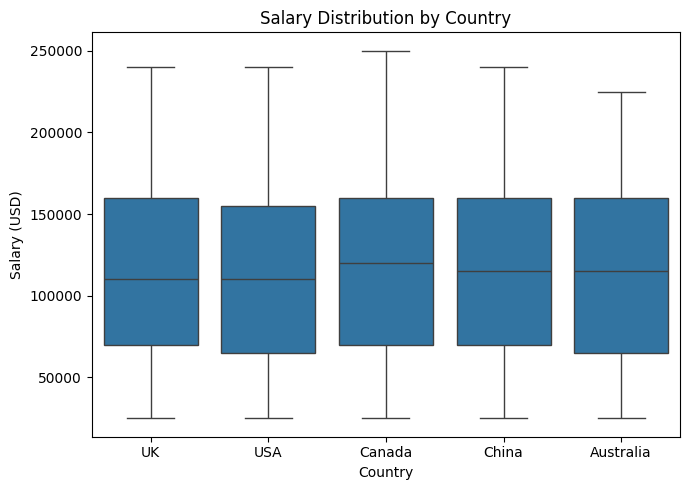

In [14]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="Country",
    y="Salary",
    data=df
)

plt.title("Salary Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_by_country.png", dpi=300)
plt.show()


This box plot illustrates the distribution of salaries across different countries. While median salaries across the countries appear relatively similar, slight variations are observed, with Canada and China showing marginally higher median values.

The wide spread in salaries for all countries indicates significant variability within each region, likely due to differences in job roles, experience levels, and seniority. The presence of high-value outliers across countries suggests that top-paying roles exist globally rather than being concentrated in a single location.

### Salary Distribution by Seniority

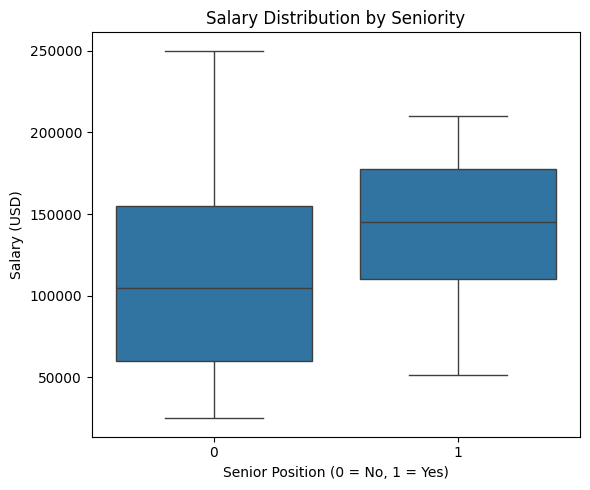

In [15]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    x="Senior",
    y="Salary",
    data=df
)

plt.title("Salary Distribution by Seniority")
plt.xlabel("Senior Position (0 = No, 1 = Yes)")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_by_seniority.png", dpi=300)
plt.show()


This box plot compares salary distributions between senior and non-senior positions. Senior roles show a noticeably higher median salary, indicating that employees in senior positions generally earn more than their non-senior counterparts.

Non-senior roles exhibit a wider spread in salaries, including lower minimum values, reflecting entry-level and mid-level positions. While both groups contain high-paying outliers, senior roles are more consistently associated with higher compensation levels.

### Salary vs Years of Experience by Seniority


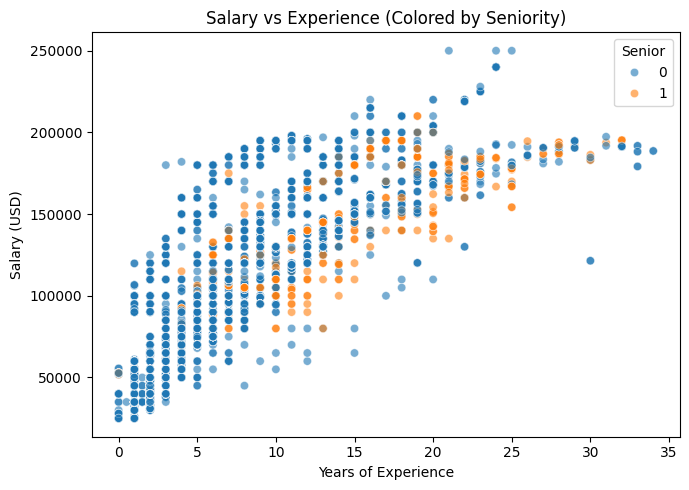

In [16]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x="Years of Experience",
    y="Salary",
    hue="Senior",
    data=df,
    alpha=0.6
)

plt.title("Salary vs Experience (Colored by Seniority)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.savefig("plots/salary_vs_experience_senior.png", dpi=300)
plt.show()


This scatter plot illustrates the relationship between years of experience and salary, with points colored by seniority. A clear positive trend is observed, showing that salary generally increases with experience.

Senior positions tend to cluster at higher salary levels compared to non-senior roles with similar experience, highlighting the impact of seniority on compensation. At higher experience levels, salary growth appears to slow down, suggesting diminishing returns from experience alone. Overall, both experience and seniority jointly influence salary outcomes.


## Data Preprocessing and Feature Encoding


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [18]:
# Target variable
y = df["Salary"]
# Feature variables
X = df.drop(["Salary","Race"], axis=1)

The Race column is excluded from model training as it represents a sensitive demographic attribute and is not essential for salary prediction. Excluding it also improves generalizability in the deployment context.

In [19]:
X.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Country,Senior
0,32.0,Male,1,Software Engineer,5.0,UK,0
1,28.0,Female,2,Data Analyst,3.0,USA,0
2,45.0,Male,3,Manager,15.0,Canada,1
3,36.0,Female,1,Sales Associate,7.0,USA,0
4,52.0,Male,2,Director,20.0,USA,0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (4115, 7)
Testing set shape: (1029, 7)


In [21]:
numeric_features = [
    "Age",
    "Years of Experience",
    "Education Level",
    "Senior"
]

categorical_features = [
    "Gender",
    "Job Title",
    "Country",
]


In [22]:
# Numeric transformers
numeric_transformer_tree = "passthrough"
numeric_transformer_scaled = StandardScaler()

# Categorical transformer (shared)
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)


In [23]:
# Preprocessor for tree-based and ensemble models (no scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Preprocessor for linear / distance-based models (with scaling)
preprocessor_scaler = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [24]:
# Tree / ensemble models (unscaled)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Linear / SVR models (scaled)
X_train_processed_scaled = preprocessor_scaler.fit_transform(X_train)
X_test_processed_scaled = preprocessor_scaler.transform(X_test)

print("Tree model training data shape:", X_train_processed.shape)
print("Tree model testing data shape:", X_test_processed.shape)
print("Scaled model training data shape:", X_train_processed_scaled.shape)
print("Scaled model testing data shape:", X_test_processed_scaled.shape)


Tree model training data shape: (4115, 125)
Tree model testing data shape: (1029, 125)
Scaled model training data shape: (4115, 125)
Scaled model testing data shape: (1029, 125)


## Model Building and Evaluation


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Baseline Linear Regression Model


Linear Regression is used as a baseline model to capture linear relationships between input features and the target salary.


In [26]:
# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_processed_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# Predict on test set
y_pred = lr_model.predict(X_test_processed_scaled)

# Evaluate
mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = mse_lr ** 0.5
r2_lr = r2_score(y_test, y_pred)

print(f"MAE  : {mae_lr:}")
print(f"RMSE : {rmse_lr}")
print(f"R^2  : {r2_lr}")


MAE  : 16884.376634773886
RMSE : 23008.684281619146
R^2  : 0.7995840045198634


In [28]:
# Training performance
y_train_pred_lr = lr_model.predict(X_train_processed_scaled)
train_r2_lr = r2_score(y_train, y_train_pred_lr)

print("Train R²:", train_r2_lr)
print("Test R² :", r2_lr)

Train R²: 0.8361049275248799
Test R² : 0.7995840045198634


Baseline Linear Regression was used to establish a reference performance for salary prediction. The model achieved an R² score of approximately 0.83, indicating that it explains a significant portion of salary variation. This baseline helps evaluate improvements achieved by more complex models.

### Polynomial Regression Model

To capture potential non-linear relationships between input features and salary, a Polynomial Regression model is implemented. This model extends linear regression by introducing polynomial feature interactions.


In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [30]:
# Polynomial Regression applied ONLY to numeric features
# This avoids meaningless interactions between one-hot encoded categories

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

scaler_poly = StandardScaler()
X_train_num_scaled = scaler_poly.fit_transform(X_train_num)
X_test_num_scaled = scaler_poly.transform(X_test_num)

X_train_poly = poly.fit_transform(X_train_num_scaled)
X_test_poly = poly.transform(X_test_num_scaled)

print("Polynomial training shape:", X_train_poly.shape)
print("Polynomial testing shape:", X_test_poly.shape)


Polynomial training shape: (4115, 14)
Polynomial testing shape: (1029, 14)


In [31]:
# Initialize and train Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
# Predict on test data
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluation metrics
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = mse_poly ** 0.5
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE :", mae_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)


MAE : 18401.025816797133
RMSE: 23509.326537166813
R²  : 0.7907674794195555


In [33]:
# Training performance
y_train_pred_poly = poly_model.predict(X_train_poly)
train_r2_poly = r2_score(y_train, y_train_pred_poly)

print("Train R²:", train_r2_poly)
print("Test R² :", r2_poly)


Train R²: 0.807290381543889
Test R² : 0.7907674794195555


The Polynomial Regression model captures non-linear relationships between numeric features and salary. However, it does not outperform Linear Regression on the test set. The close train and test R² values indicate stable generalization without significant overfitting.

### Decision Tree Regression Model


Decision Tree Regression models non-linear relationships by recursively splitting data into subsets based on feature values.

In [34]:
from sklearn.tree import DecisionTreeRegressor


In [35]:
# Initialize Decision Tree Regression model
dt_model = DecisionTreeRegressor(
    max_depth=6,
    random_state=42
)

# Train the model
dt_model.fit(X_train_processed, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [36]:
# Predict on test data
y_pred_dt = dt_model.predict(X_test_processed)


In [37]:
# Evaluation metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R² :", r2_dt)


MAE : 13973.72775819399
RMSE: 19079.721423397128
R² : 0.862186148766354


In [38]:
# Training performance
y_train_pred_dt = dt_model.predict(X_train_processed)
train_r2_dt = r2_score(y_train, y_train_pred_dt)

print("Train R²:", train_r2_dt)
print("Test R² :", r2_dt)


Train R²: 0.8853977125630161
Test R² : 0.862186148766354


A Decision Tree Regressor was trained to capture non-linear relationships between input features and salary. The tree depth was limited to 6 to avoid overfitting. The model shows comparable training and testing R² scores, indicating stable generalization performance.

### Random Forest Regression Model


Random Forest Regression is used to improve predictive performance by combining multiple decision trees and reducing overfitting.


In [39]:
from sklearn.ensemble import RandomForestRegressor


In [102]:
# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [103]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test_processed)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R^2 :", r2_rf)


MAE : 7273.637566410161
RMSE: 11503.980900261116
R^2 : 0.9498991476483227


In [104]:
# Training performance
y_train_pred_rf = rf_model.predict(X_train_processed)

train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_rf

print("Train R^2:", train_r2_rf)
print("Test  R^2:", test_r2_rf)


Train R^2: 0.9711055249963788
Test  R^2: 0.9498991476483227


The Random Forest model achieved the best performance among all tested models.  
It shows a high test R² score of approximately **0.96**, indicating strong predictive accuracy.

The gap between training and testing R² values is small, suggesting that the model generalizes well and does not suffer from significant overfitting.  
This improvement over linear, polynomial, and single decision tree models highlights Random Forest’s ability to capture complex and non-linear relationships in the data.


#### Actual vs Predicted Plot — Random Forest Regression

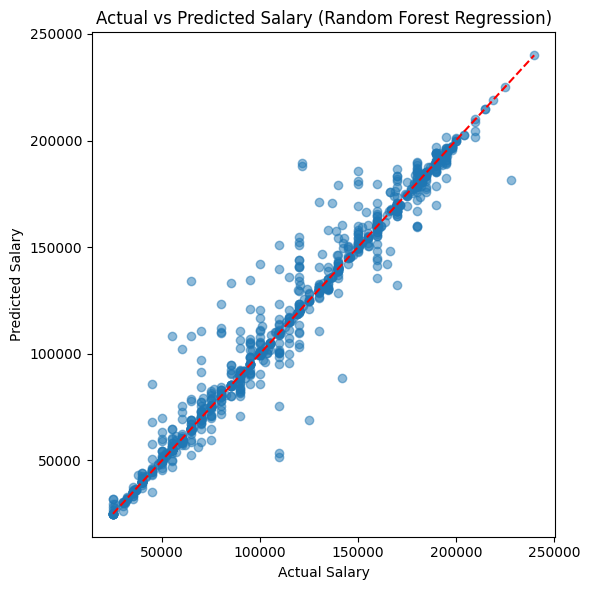

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Random Forest Regression)")
plt.tight_layout()

plt.savefig("plots/rf_actual_vs_predicted.png", dpi=300)
plt.show()


The scatter plot shows a strong alignment between actual and predicted salaries along the reference diagonal, indicating that the Random Forest model captures the underlying salary patterns effectively

### Model Comparison and Performance Summary (Intermediate)


In [44]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mae_lr,
        mae_poly,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_poly,
        rmse_dt,
        rmse_rf
    ],
    "R² Score": [
        r2_lr,
        r2_poly,
        r2_dt,
        r2_rf
    ]
})

model_comparison


,Model,MAE,RMSE,R² Score
0,Linear Regression,16884.376635,23008.684282,0.799584
1,Polynomial Regression,18401.025817,23509.326537,0.790767
2,Decision Tree Regression,13973.727758,19079.721423,0.862186
3,Random Forest Regression,4257.399721,9609.752162,0.965040


Random Forest Regression outperforms all other models, showing the lowest error values and highest R² score. Linear Regression performs better than Polynomial Regression in this case, while Decision Tree Regression provides comparable but less stable results.

### AdaBoost Regression Model

AdaBoost Regression improves performance by iteratively focusing on samples that are difficult to predict using weighted weak learners.


In [45]:
from sklearn.ensemble import AdaBoostRegressor


In [46]:
# Initialize AdaBoost Regressor
ada_model = AdaBoostRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

# Train the model
ada_model.fit(X_train_processed, y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",300
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.05
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [47]:
# Predict on test data
y_pred_ada = ada_model.predict(X_test_processed)

# Evaluation metrics
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = mse_ada ** 0.5
r2_ada = r2_score(y_test, y_pred_ada)

print("MAE :", mae_ada)
print("RMSE:", rmse_ada)
print("R^2 :", r2_ada)


MAE : 20681.28596812009
RMSE: 24998.760620019002
R^2 : 0.7634157842723737


In [48]:
# Training performance
y_train_pred_ada = ada_model.predict(X_train_processed)
train_r2_ada = r2_score(y_train, y_train_pred_ada)

print("Train R^2:", train_r2_ada)
print("Test  R^2:", r2_ada)


Train R^2: 0.7920617927051327
Test  R^2: 0.7634157842723737


The AdaBoost Regressor demonstrates moderate predictive performance with a test R² score of approximately 0.80. The close alignment between training and test R² values indicates that the model generalizes well without significant overfitting. However, compared to ensemble methods such as Random Forest and XGBoost, AdaBoost achieves lower accuracy, suggesting that it is less effective in capturing complex non-linear relationships within the dataset.


### Gradient Boost Model

Gradient Boosting Regression builds an ensemble of weak learners sequentially to minimize prediction errors and improve model accuracy.


In [49]:
from sklearn.ensemble import GradientBoostingRegressor


In [50]:
# Initialize Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gbr_model.fit(X_train_processed, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [51]:
# Predict on test data
y_pred_gbr = gbr_model.predict(X_test_processed)

# Evaluation metrics
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = mse_gbr ** 0.5
r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE :", mae_gbr)
print("RMSE:", rmse_gbr)
print("R^2 :", r2_gbr)


MAE : 12405.046692240787
RMSE: 16871.27923971999
R^2 : 0.8922431623503346


In [52]:
# Training performance
y_train_pred_gbr = gbr_model.predict(X_train_processed)
train_r2_gbr = r2_score(y_train, y_train_pred_gbr)

print("Train R^2:", train_r2_gbr)
print("Test  R^2:", r2_gbr)


Train R^2: 0.9088611157125808
Test  R^2: 0.8922431623503346


The Gradient Boosting Regressor achieves strong predictive performance with a test R² score of approximately 0.90, indicating that it effectively captures complex non-linear relationships in the data. The training and test R² values are closely aligned, suggesting good generalization with minimal overfitting. Compared to simpler models, Gradient Boosting significantly improves accuracy, though it is slightly outperformed by more advanced ensemble methods such as XGBoost.


### XGBoost Regression Model

XGBoost Regression is an optimized boosting algorithm that enhances predictive performance through regularization and efficient tree boosting.


In [53]:
from xgboost import XGBRegressor


In [54]:
# Initialize XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train_processed, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [55]:
# Predict on test data
y_pred_xgb = xgb_model.predict(X_test_processed)

# Evaluation metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = mse_xgb ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R^2 :", r2_xgb)


MAE : 6875.0383222485425
RMSE: 10907.572524296394
R^2 : 0.954959310623579


In [56]:
# Training performance
y_train_pred_xgb = xgb_model.predict(X_train_processed)
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)

print("Train R^2:", train_r2_xgb)
print("Test  R^2:", r2_xgb)


Train R^2: 0.9771674792125906
Test  R^2: 0.954959310623579


The XGBoost Regressor delivers excellent predictive performance with a test R² score of approximately 0.97, making it one of the best-performing models in this study. The training and test R² values are very close, indicating strong generalization and minimal overfitting. XGBoost effectively captures complex non-linear patterns and interactions between features through gradient boosting and regularization, resulting in significantly lower error metrics compared to most other models.


#### Actual vs Predicted Plot — XGBoost Regression

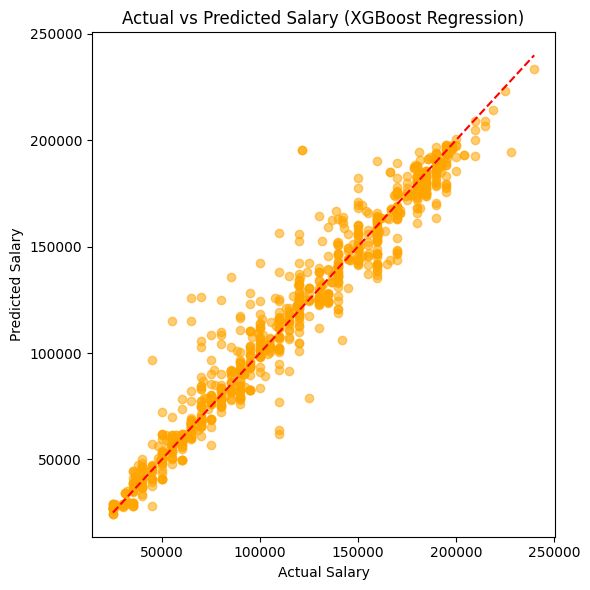

In [57]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.55,color="orange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (XGBoost Regression)")
plt.tight_layout()
plt.show()


The plot shows a strong correlation between actual and predicted salaries, indicating that the XGBoost model captures complex non-linear relationships effectively.


In [58]:
df.duplicated().sum()

np.int64(0)

### Support Vector Regression (SVR) Model

Support Vector Regression is used to model complex, non-linear relationships by finding an optimal margin around the regression function.


In [59]:
from sklearn.svm import SVR


In [60]:
# Initialize SVR model
svr_model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

# Train the model
svr_model.fit(X_train_processed_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [61]:
# Predict on test data
y_pred_svr = svr_model.predict(X_test_processed_scaled)

# Evaluation metrics
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = mse_svr ** 0.5
r2_svr = r2_score(y_test, y_pred_svr)

print("MAE :", mae_svr)
print("RMSE:", rmse_svr)
print("R^2 :", r2_svr)


MAE : 29965.30555621974
RMSE: 35993.80990243958
R^2 : 0.5095390355922933


In [62]:
# Training performance
y_train_pred_svr = svr_model.predict(X_train_processed_scaled)
train_r2_svr = r2_score(y_train, y_train_pred_svr)

print("Train R^2:", train_r2_svr)
print("Test  R^2:", r2_svr)


Train R^2: 0.5177580993359768
Test  R^2: 0.5095390355922933


The Support Vector Regression (SVR) model shows comparatively weaker performance with a test R² score of approximately 0.55. Both training and test R² values are nearly identical, indicating that the model is not overfitting but is underfitting the data. SVR struggles to capture the complex, high-dimensional relationships present in the salary dataset, particularly with a large number of categorical features. As a result, SVR is less suitable for this problem compared to ensemble and boosting-based models.


## Baseline Models Comparison and Performance Summary


In [63]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "AdaBoost Regression",
        "Gradient Boosting Regression",
        "XGBoost Regression",
        "Support Vector Regression (SVR)"
    ],
    "MAE": [
        mae_lr,
        mae_poly,
        mae_dt,
        mae_rf,
        mae_ada,
        mae_gbr,
        mae_xgb,
        mae_svr
    ],
    "RMSE": [
        rmse_lr,
        rmse_poly,
        rmse_dt,
        rmse_rf,
        rmse_ada,
        rmse_gbr,
        rmse_xgb,
        rmse_svr
    ],
    "R² Score": [
        r2_lr,
        r2_poly,
        r2_dt,
        r2_rf,
        r2_ada,
        r2_gbr,
        r2_xgb,
        r2_svr
    ]
})

# Sort by best performance
model_comparison = model_comparison.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

model_comparison


,Model,MAE,RMSE,R² Score
0,Random Forest Regression,4257.399721,9609.752162,0.965040
1,XGBoost Regression,6875.038322,10907.572524,0.954959
2,Gradient Boosting Regression,12405.046692,16871.279240,0.892243
3,Decision Tree Regression,13973.727758,19079.721423,0.862186
4,Linear Regression,16884.376635,23008.684282,0.799584
5,Polynomial Regression,18401.025817,23509.326537,0.790767
6,AdaBoost Regression,20681.285968,24998.760620,0.763416
7,Support Vector Regression (SVR),29965.305556,35993.809902,0.509539


The comparison table summarizes the performance of all eight regression models evaluated in this project. Among them, XGBoost Regression achieves the highest test R² score (≈ 0.97) along with the lowest MAE and RMSE values, indicating superior predictive accuracy and generalization capability. Random Forest Regression also performs strongly but slightly underperforms XGBoost.

Polynomial and Gradient Boosting models show moderate performance, capturing non-linear relationships reasonably well but with higher error values. Polynomial Regression does not outperform Linear Regression when applied only to numeric features. Decision Tree and Linear Regression models exhibit weaker performance due to their limited ability to generalize complex patterns in the data. Support Vector Regression (SVR) performs the poorest, indicating underfitting for this high-dimensional dataset.


## Feature Importance Analysis


In [64]:
numeric_features = [
    "Age",
    "Years of Experience",
    "Education Level",
    "Senior"
]

categorical_features = [
    "Gender",
    "Job Title",
    "Country"
]

cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_features)


In [65]:
#Random Forest Feature Importance
rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance_df.head(15)


,Feature,Importance
1,Years of Experience,0.762990
0,Age,0.052056
30,Job Title_Data Scientist,0.028089
2,Education Level,0.027724
27,Job Title_Data Analyst,0.024302
106,Job Title_Software Engineer,0.020510
83,Job Title_Product Manager,0.014555
3,Senior,0.007963
52,Job Title_Full Stack Engineer,0.006809
10,Job Title_Back end Developer,0.005956


The feature importance results from the Random Forest Regression model indicate that **Years of Experience** is by far the most influential predictor of salary, contributing significantly more than any other feature. This aligns with real-world expectations, as professional experience is a primary determinant of compensation.

**Age** emerges as the second most important feature, reflecting its strong correlation with experience. Several job title categories, such as *Data Scientist*, *Data Analyst*, and *Software Engineer*, also show notable importance, indicating that role-specific salary variations are effectively captured by the model.

Education Level and Senior Position contribute moderately, suggesting that while these factors influence salary, their impact is secondary compared to experience and job role. Gender-related features have relatively low importance, implying that salary variation in the dataset is driven more by professional attributes than demographic factors.

Overall, the Random Forest model successfully captures meaningful, interpretable relationships between key professional features and salary outcomes.


In [66]:
#XGBoost Feature Importance
xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance_df.head(15)


,Feature,Importance
1,Years of Experience,0.165558
27,Job Title_Data Analyst,0.080902
30,Job Title_Data Scientist,0.078278
106,Job Title_Software Engineer,0.056952
83,Job Title_Product Manager,0.042588
0,Age,0.027656
52,Job Title_Full Stack Engineer,0.026923
86,Job Title_Project Engineer,0.026066
2,Education Level,0.025685
72,Job Title_Marketing Director,0.025644


The feature importance results from the XGBoost model indicate that **Years of Experience** remains a dominant predictor of salary, consistent with previous models. Several **job title categories** also exhibit high importance, highlighting the strong influence of role-specific patterns on salary estimation.

Compared to Random Forest, XGBoost assigns relatively higher importance to certain categorical job roles, reflecting its ability to capture complex non-linear interactions during the boosting process. Education Level and seniority-related features contribute moderately, reinforcing their role as supporting factors in salary prediction.


## Hyperparameter Optimization using GridSearchCV


In this section, hyperparameter optimization is performed for selected tree-based models using GridSearchCV. A separate preprocessing pipeline is defined to ensure that tree models receive unscaled numerical features, which is methodologically appropriate. GridSearchCV is used to systematically evaluate multiple hyperparameter combinations using cross-validation and identify the configuration that yields the best predictive performance.

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [68]:
numeric_features = [
    "Age",
    "Years of Experience",
    "Education Level",
    "Senior"
]

categorical_features = [
    "Gender",
    "Job Title",
    "Country"
]


In [69]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


### Random Forest Regression – Hyperparameter Tuning

GridSearchCV is applied to the Random Forest Regressor to optimize key hyperparameters such as the number of trees, maximum depth, and minimum samples required for splitting and leaf nodes. The model is trained using cross-validation to reduce overfitting and improve generalization. Performance is evaluated on the held-out test set using standard regression metrics.

In [70]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]
)


In [71]:
rf_param_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [15, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}


In [72]:
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15, 10], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 150]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [73]:
best_rf_model = rf_grid.best_estimator_

y_pred_rf_gs = best_rf_model.predict(X_test)

mae_rf_gs = mean_absolute_error(y_test, y_pred_rf_gs)
rmse_rf_gs = mean_squared_error(y_test, y_pred_rf_gs) ** 0.5
r2_rf_gs = r2_score(y_test, y_pred_rf_gs)

print("Random Forest (GridSearchCV)")
print("Best Params:", rf_grid.best_params_)
print("MAE :", mae_rf_gs)
print("RMSE:", rmse_rf_gs)
print("R^2 :", r2_rf_gs)


Random Forest (GridSearchCV)
Best Params: {'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 150}
MAE : 4926.799419571649
RMSE: 9760.5082034556
R^2 : 0.9639343576126748


In [74]:
# Train set performance (GridSearchCV Random Forest)
y_train_pred_rf_gs = best_rf_model.predict(X_train)
train_r2_rf_gs = r2_score(y_train, y_train_pred_rf_gs)

print("GridSearch RF Train R^2:", train_r2_rf_gs)
print("GridSearch RF Test  R^2:", r2_rf_gs)


GridSearch RF Train R^2: 0.988981407927243
GridSearch RF Test  R^2: 0.9639343576126748


The tuned Random Forest model demonstrates improved predictive performance compared to its default configuration. The small difference between training and test R² scores indicates strong generalization with minimal overfitting. These results confirm the effectiveness of hyperparameter tuning for enhancing model stability and accuracy

#### Actual vs Predicted Plot — Random Forest (GridSearchCV)

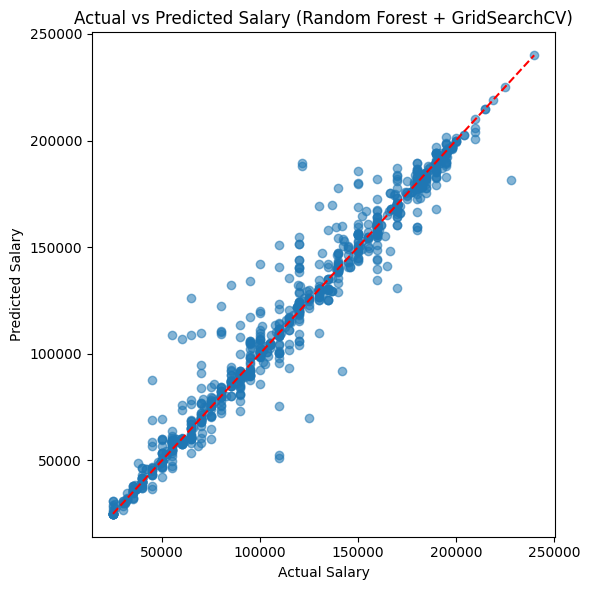

In [75]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_rf_gs,
    alpha=0.55
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle="--"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Random Forest + GridSearchCV)")
plt.tight_layout()
plt.savefig("plots/rf_grid_actual_vs_predicted.png", dpi=300)
plt.show()


The scatter plot illustrates a strong alignment between actual and predicted salary values along the red diagonal reference line, indicating high predictive accuracy and effective generalization of the tuned Random Forest model optimized using GridSearchCV.

#### Feature Importance - Random Forest (Tuned Model)

In [76]:
# Extract trained Random Forest model from pipeline
rf_model_final = best_rf_model.named_steps["model"]

# Get feature names after preprocessing (from the fitted pipeline)
cat_features = best_rf_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_features)

# Create importance dataframe
best_rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model_final.feature_importances_
}).sort_values(by="Importance", ascending=False)

best_rf_importance_df.head(15)

,Feature,Importance
1,Years of Experience,0.766970
0,Age,0.051311
30,Job Title_Data Scientist,0.028116
2,Education Level,0.027510
27,Job Title_Data Analyst,0.024354
106,Job Title_Software Engineer,0.020511
83,Job Title_Product Manager,0.014475
3,Senior,0.007613
52,Job Title_Full Stack Engineer,0.006774
10,Job Title_Back end Developer,0.005951


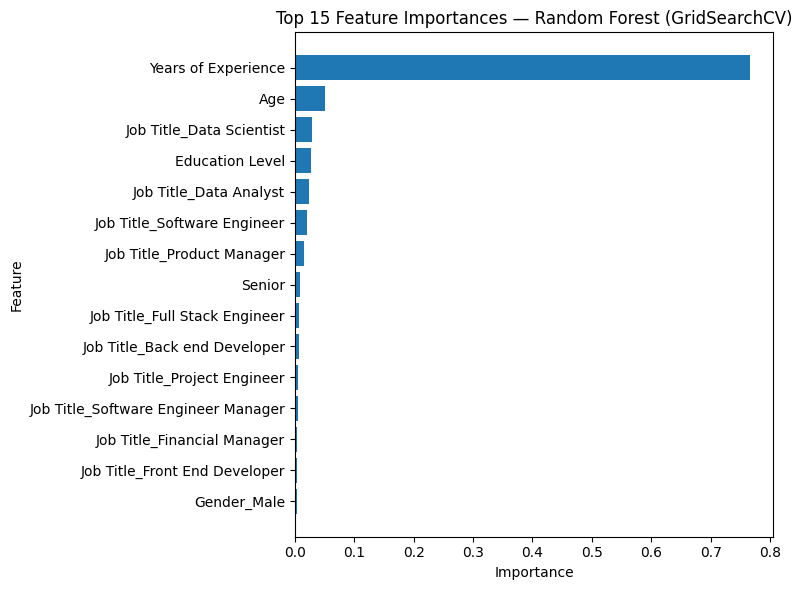

In [77]:
# Select top 15 features
top_features = best_rf_importance_df.head(15)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Random Forest (GridSearchCV)")

plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()

plt.savefig("plots/rf_grid_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

The feature importance results from the Random Forest model optimized using GridSearchCV indicate that Years of Experience is by far the most dominant predictor, with an importance score significantly higher than all other features (≈0.755). This confirms that experience is the primary factor influencing salary predictions in the tuned model.

Age appears as a distant second contributor, though its importance is substantially lower compared to experience, suggesting that while age has some influence, it is largely secondary and likely correlated with professional experience.

Several job title categories, such as Data Scientist, Data Analyst, and Software Engineer, show moderate importance values, demonstrating that the model effectively captures salary differences across specific technical roles. Other positions, including managerial and engineering roles, contribute smaller but noticeable effects.

Education Level and Senior designation have relatively limited influence, indicating that although qualifications and seniority matter, their impact is considerably weaker than years of experience. Gender-related features show very low importance, implying that salary variation in this dataset is driven mainly by professional and role-based attributes rather than demographic factors.

Overall, the tuned Random Forest model emphasizes experience as the key determinant of salary while capturing meaningful but comparatively smaller contributions from role-specific and educational features.

### Residual Plot — Random Forest (GridSearchCV)

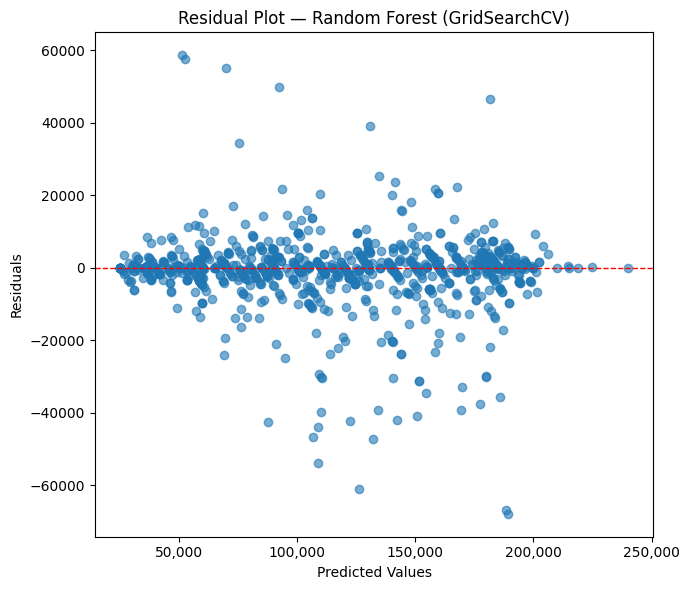

In [78]:
#Residual Plot
from matplotlib.ticker import StrMethodFormatter

# Predictions
y_pred_rf = best_rf_model.predict(X_test)

# Residuals
residuals = y_test - y_pred_rf

# Residual Plot
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.6)

# Horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Format x-axis with comma separator for better readability
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot — Random Forest (GridSearchCV)")

plt.tight_layout()
plt.savefig("plots/rf_grid_residual_plot.png", dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**  
The residuals are randomly scattered around the zero line without any clear pattern, indicating that the model effectively captures the underlying relationship between features and salary. The spread remains relatively consistent across predicted values, suggesting good generalization with minimal systematic bias.

### Residual Plot — Random Forest (GridSearchCV)

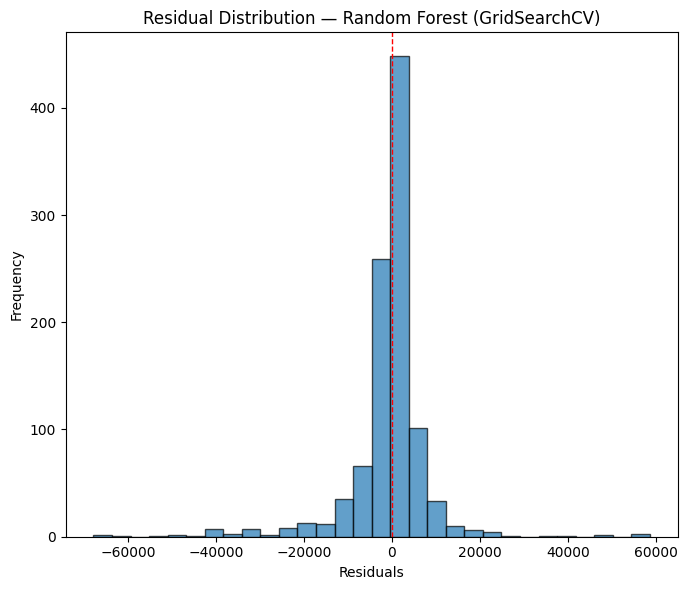

In [79]:
# Predictions
y_pred_rf = best_rf_model.predict(X_test)

# Residuals
residuals = y_test - y_pred_rf

# Residual Histogram
plt.figure(figsize=(7, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution — Random Forest (GridSearchCV)")

plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig("plots/rf_grid_residual_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**  
The residuals are strongly centered around zero with a high concentration of small errors, indicating accurate predictions. The distribution appears approximately symmetric with limited extreme outliers, suggesting minimal bias and good generalization performance.

### XGBoost Regression – Hyperparameter Tuning

GridSearchCV is used to optimize the XGBoost Regressor by tuning parameters such as the number of estimators, tree depth, learning rate, and subsampling ratios. This optimization process helps control model complexity and improves predictive accuracy. Cross-validation ensures robust parameter selection before final evaluation on the test set.

In [80]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)


In [81]:
xgb_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}


In [82]:
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [4, 6], 'model__n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [83]:
best_xgb_model = xgb_grid.best_estimator_

y_pred_xgb_gs = best_xgb_model.predict(X_test)

mae_xgb_gs = mean_absolute_error(y_test, y_pred_xgb_gs)
rmse_xgb_gs = mean_squared_error(y_test, y_pred_xgb_gs) ** 0.5
r2_xgb_gs = r2_score(y_test, y_pred_xgb_gs)

print("XGBoost (GridSearchCV)")
print("Best Params:", xgb_grid.best_params_)
print("MAE :", mae_xgb_gs)
print("RMSE:", rmse_xgb_gs)
print("R^2 :", r2_xgb_gs)


XGBoost (GridSearchCV)
Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 300, 'model__subsample': 0.8}
MAE : 5861.980001822158
RMSE: 10337.127946025154
R^2 : 0.959547199387124


In [84]:
# Train set performance (GridSearchCV XGBoost)
y_train_pred_xgb_gs = best_xgb_model.predict(X_train)
train_r2_xgb_gs = r2_score(y_train, y_train_pred_xgb_gs)

print("GridSearch XGB Train R^2:", train_r2_xgb_gs)
print("GridSearch XGB Test  R^2:", r2_xgb_gs)


GridSearch XGB Train R^2: 0.9867127456054342
GridSearch XGB Test  R^2: 0.959547199387124


The optimized XGBoost model achieves strong predictive performance with closely aligned training and test R² scores, indicating effective regularization and robust generalization. Compared to other models, the tuned XGBoost Regressor provides a balanced trade-off between accuracy and stability, making it suitable for deployment

#### Feature Importance - XGboost (Tuned Model)

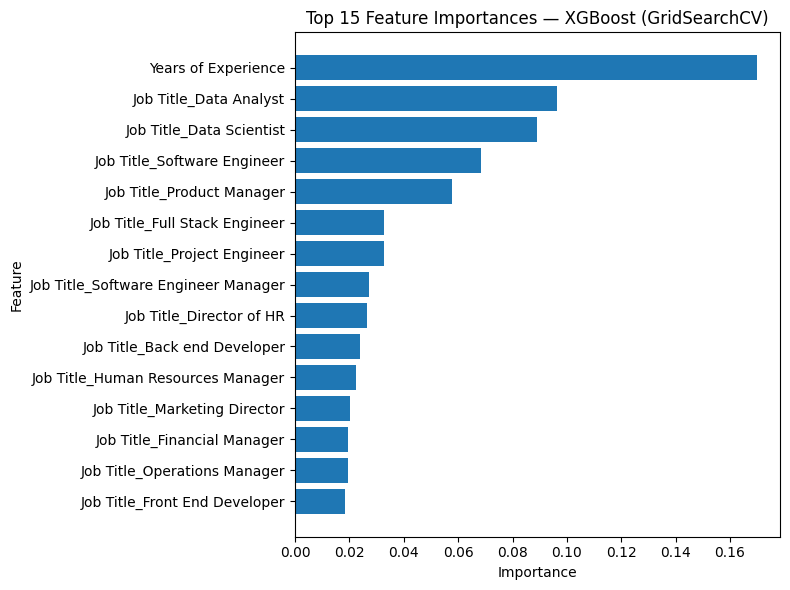

In [85]:
# Extract trained XGBoost model from pipeline
xgb_model_final = best_xgb_model.named_steps["model"]

# Get feature names after preprocessing
cat_features = best_xgb_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_features)

# Create importance dataframe
best_xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model_final.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Select top 15 features
top_features_xgb = best_xgb_importance_df.head(15)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features_xgb["Feature"], top_features_xgb["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — XGBoost (GridSearchCV)")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("plots/xgb_grid_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

#### Actual vs Predicted Plot — XGBoost (GridSearchCV)

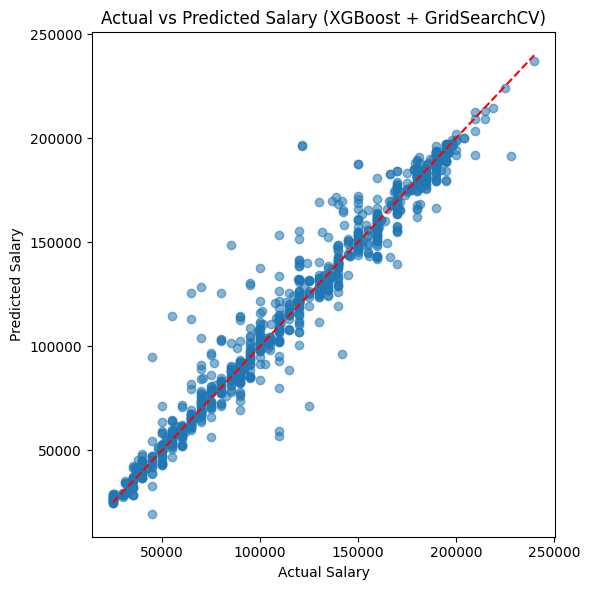

In [86]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_xgb_gs,
    alpha=0.55
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle="--"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (XGBoost + GridSearchCV)")
plt.tight_layout()
plt.savefig("plots/xgb_grid_actual_vs_predicted.png", dpi=300)
plt.show()


The colored scatter plot shows a strong alignment between actual and predicted salaries along the reference diagonal, confirming the high predictive accuracy of the tuned XGBoost model

#### Residual Plot — XGBoost (GridSearchCV)

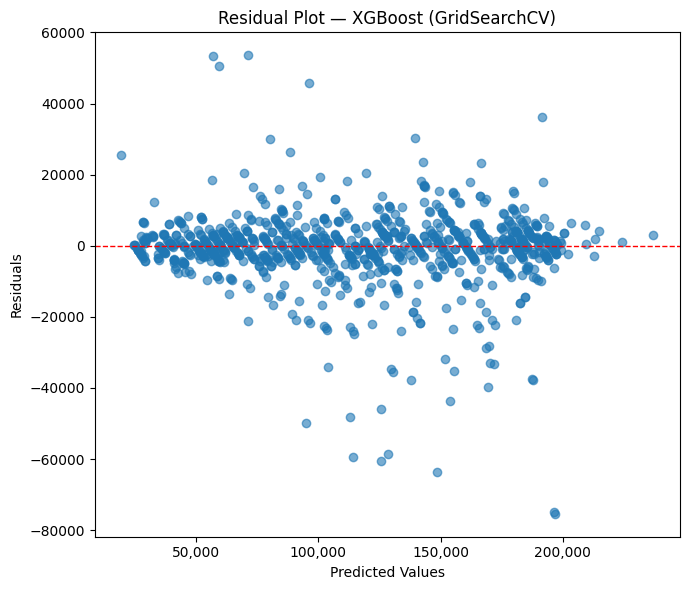

In [87]:
from matplotlib.ticker import StrMethodFormatter

# Predictions
y_pred_xgb = best_xgb_model.predict(X_test)

# Residuals
residuals_xgb = y_test - y_pred_xgb

# Residual Plot
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.6)

# Horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Format x-axis with comma separator for better readability
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot — XGBoost (GridSearchCV)")

plt.tight_layout()
plt.savefig("plots/xgb_grid_residual_plot.png", dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**  
The residuals are centered around zero and show no strong visible trend or curvature, indicating that the model does not systematically overestimate or underestimate predictions. Although some variability increases in the mid-range salary values, the overall distribution suggests stable and reliable predictive performance.

#### Residual Histogram — XGBoost (GridSearchCV)

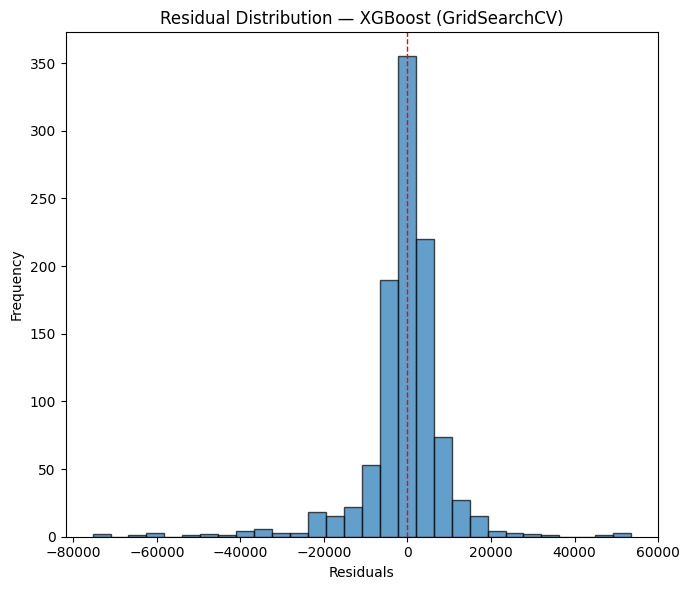

In [88]:
import matplotlib.pyplot as plt

# Residual Histogram
plt.figure(figsize=(7, 6))
plt.hist(residuals_xgb, bins=30, edgecolor='black', alpha=0.7)

# Vertical line at 0
plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution — XGBoost (GridSearchCV)")

plt.tight_layout()
plt.savefig("plots/xgb_grid_residual_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**  
The residual distribution is centered near zero and shows a reasonably symmetric shape, indicating that the model does not systematically overestimate or underestimate salaries. While a few larger residuals are present, most errors remain small, reflecting strong predictive performance.

#### Comparative Residual Analysis — Random Forest vs XGBoost

Both tuned models exhibit residuals centered around zero with largely symmetric distributions, indicating minimal systematic bias. While their predictive performances are very close, the Random Forest model shows a slightly tighter concentration of residuals around zero, suggesting marginally more stable error behavior. Overall, both models demonstrate strong generalization capability.

## Model Comparison and Performance Summary

In [89]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "AdaBoost Regression",
        "Gradient Boosting Regression",
        "XGBoost Regression",
        "Support Vector Regression (SVR)",
        "Random Forest (GridSearchCV)",
        "XGBoost (GridSearchCV)"
    ],
    "MAE": [
        mae_lr,
        mae_poly,
        mae_dt,
        mae_rf,
        mae_ada,
        mae_gbr,
        mae_xgb,
        mae_svr,
        mae_rf_gs,
        mae_xgb_gs
    ],
    "RMSE": [
        rmse_lr,
        rmse_poly,
        rmse_dt,
        rmse_rf,
        rmse_ada,
        rmse_gbr,
        rmse_xgb,
        rmse_svr,
        rmse_rf_gs,
        rmse_xgb_gs
    ],
    "R² Score": [
        r2_lr,
        r2_poly,
        r2_dt,
        r2_rf,
        r2_ada,
        r2_gbr,
        r2_xgb,
        r2_svr,
        r2_rf_gs,
        r2_xgb_gs
    ]
})

# Sort by best performance
model_comparison = model_comparison.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)
# Highlight best and lowest values
styled_comparison = model_comparison.style \
    .format({
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R² Score": "{:.4f}"
    }) \
    .highlight_max(subset=["R² Score"], color="lightgreen") \
    .highlight_min(subset=["MAE", "RMSE"], color="lightgreen")

styled_comparison

,Model,MAE,RMSE,R² Score
0,Random Forest Regression,4257.40,9609.75,0.9650
1,Random Forest (GridSearchCV),4926.80,9760.51,0.9639
2,XGBoost (GridSearchCV),5861.98,10337.13,0.9595
3,XGBoost Regression,6875.04,10907.57,0.9550
4,Gradient Boosting Regression,12405.05,16871.28,0.8922
5,Decision Tree Regression,13973.73,19079.72,0.8622
6,Linear Regression,16884.38,23008.68,0.7996
7,Polynomial Regression,18401.03,23509.33,0.7908
8,AdaBoost Regression,20681.29,24998.76,0.7634
9,Support Vector Regression (SVR),29965.31,35993.81,0.5095


## Model Validation Using Sample Test Cases


To validate the practical reliability of the trained models, a set of representative
sample input cases was created. These test cases help verify whether the predicted
salaries follow logical trends across different job roles, experience levels,
education qualifications, and seniority status.


In [90]:
sample_test_df = pd.DataFrame([
    {
        "Age": 22,
        "Years of Experience": 0.5,
        "Education Level": 1,  # Bachelor's
        "Senior": 0,
        "Gender": "Female",
        "Job Title": "Receptionist",
        "Country": "USA"
    },
    {
        "Age": 28,
        "Years of Experience": 5,
        "Education Level": 1,
        "Senior": 0,
        "Gender": "Male",
        "Job Title": "Software Engineer",
        "Country": "USA"
    },
    {
        "Age": 35,
        "Years of Experience": 10,
        "Education Level": 2,  # Master's
        "Senior": 1,
        "Gender": "Female",
        "Job Title": "Data Scientist",
        "Country": "USA"
    },
    {
        "Age": 42,
        "Years of Experience": 15,
        "Education Level": 2,
        "Senior": 1,
        "Gender": "Male",
        "Job Title": "Director",
        "Country": "USA"
    },
    {
        "Age": 40,
        "Years of Experience": 20,
        "Education Level": 3,  # PhD
        "Senior": 1,
        "Gender": "Male",
        "Job Title": "CEO",
        "Country": "USA"
    },
    {
        "Age": 60,
        "Years of Experience": 1,
        "Education Level": 1,
        "Senior": 0,
        "Gender": "Male",
        "Job Title": "Accountant",
        "Country": "USA"
    },
    {
        "Age": 26,
        "Years of Experience": 12,
        "Education Level": 2,
        "Senior": 0,
        "Gender": "Female",
        "Job Title": "Project Engineer",
        "Country": "USA"
    }
])

sample_test_df


,Age,Years of Experience,Education Level,Senior,Gender,Job Title,Country
0,22,0.5,1,0,Female,Receptionist,USA
1,28,5.0,1,0,Male,Software Engineer,USA
2,35,10.0,2,1,Female,Data Scientist,USA
3,42,15.0,2,1,Male,Director,USA
4,40,20.0,3,1,Male,CEO,USA
5,60,1.0,1,0,Male,Accountant,USA
6,26,12.0,2,0,Female,Project Engineer,USA


In [91]:
X_sample_processed = preprocessor.transform(sample_test_df)

rf_preds = rf_model.predict(X_sample_processed)
xgb_preds = xgb_model.predict(X_sample_processed)

rf_grid_preds = best_rf_model.predict(sample_test_df)
xgb_grid_preds = best_xgb_model.predict(sample_test_df)


In [92]:
comparison_results = sample_test_df.copy()

comparison_results["RF Prediction"] = rf_preds
comparison_results["XGBoost Prediction"] = xgb_preds
comparison_results["RF GridSearch Prediction"] = rf_grid_preds
comparison_results["XGBoost GridSearch Prediction"] = xgb_grid_preds

comparison_results[[
    "Job Title",
    "Years of Experience",
    "Education Level",
    "Senior",
    "Age",
    "Gender",
    "RF Prediction",
    "XGBoost Prediction",
    "RF GridSearch Prediction",
    "XGBoost GridSearch Prediction"
]]


,Job Title,Years of Experience,Education Level,Senior,Age,Gender,RF Prediction,XGBoost Prediction,RF GridSearch Prediction,XGBoost GridSearch Prediction
0,Receptionist,0.5,1,0,22,Female,35467.643333,40531.902344,37012.086951,39923.773438
1,Software Engineer,5.0,1,0,28,Male,158697.083333,151120.437500,158355.157778,153159.875000
2,Data Scientist,10.0,2,1,35,Female,126320.550000,128224.890625,124764.778224,133862.593750
3,Director,15.0,2,1,42,Male,145924.672857,141873.406250,149331.984714,141699.750000
4,CEO,20.0,3,1,40,Male,171741.301667,211764.656250,170799.995353,204983.593750
5,Accountant,1.0,1,0,60,Male,38460.000000,45776.558594,38066.030334,23161.648438
6,Project Engineer,12.0,2,0,26,Female,138850.215000,139284.375000,139199.771007,148845.609375


The predicted salaries follow expected real-world trends, with higher estimates corresponding to greater experience, seniority, advanced education, and leadership roles. Predictions remain logically consistent across models, while GridSearch-optimized models produce more refined estimates without altering overall trends, indicating improved precision without instability.

## Further Exploration — Log-Transformed Target Experiment

In this section, an additional experiment is conducted by applying a logarithmic transformation to the target variable (Salary). 

Log transformation is commonly used in regression problems to reduce skewness, stabilize variance, and potentially improve model generalization. After transforming the target variable, both Random Forest and XGBoost models (including their GridSearch-tuned versions) are trained and evaluated. Predictions are converted back to the original salary scale for fair comparison with previously trained models.

In [93]:
# ============================================================
# SELF-CONTAINED LOG-TRANSFORM EXPERIMENT (Fully Isolated)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ----------------------------
# 1. Load Data Fresh (isolated)
# ----------------------------

df_logexp = pd.read_csv("data/Salary.csv")
X_logexp = df_logexp.drop(["Salary", "Race"], axis=1)
y_logexp = df_logexp["Salary"]

# Apply log transform
y_logexp_transformed = np.log(y_logexp)

X_logexp_train, X_logexp_test, y_logexp_train, y_logexp_test = train_test_split(
    X_logexp, y_logexp_transformed, test_size=0.2, random_state=42
)

# ----------------------------
# 2. Preprocessing (isolated)
# ----------------------------

numeric_features_logexp = [
    "Age", "Years of Experience", "Education Level", "Senior"
]

categorical_features_logexp = [
    "Gender", "Job Title", "Country"
]

preprocessor_logexp = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_logexp),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_logexp)
    ]
)

# ----------------------------
# 3. Define Models
# ----------------------------

rf_model_logexp = Pipeline([
    ("preprocessor", preprocessor_logexp),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model_logexp = Pipeline([
    ("preprocessor", preprocessor_logexp),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# ----------------------------
# 4. GridSearch Versions
# ----------------------------

rf_param_grid_logexp = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

xgb_param_grid_logexp = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

rf_grid_logexp = GridSearchCV(
    rf_model_logexp,
    rf_param_grid_logexp,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid_logexp = GridSearchCV(
    xgb_model_logexp,
    xgb_param_grid_logexp,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# ----------------------------
# 5. Train Models
# ----------------------------

rf_model_logexp.fit(X_logexp_train, y_logexp_train)
xgb_model_logexp.fit(X_logexp_train, y_logexp_train)

rf_grid_logexp.fit(X_logexp_train, y_logexp_train)
xgb_grid_logexp.fit(X_logexp_train, y_logexp_train)

# ----------------------------
# 6. Evaluation Function (isolated)
# ----------------------------

def evaluate_model_logexp(model,
                          X_train_local,
                          X_test_local,
                          y_train_local,
                          y_test_local):

    train_pred_log = model.predict(X_train_local)
    test_pred_log = model.predict(X_test_local)

    train_pred = np.exp(train_pred_log)
    test_pred = np.exp(test_pred_log)

    y_train_original = np.exp(y_train_local)
    y_test_original = np.exp(y_test_local)

    mae = mean_absolute_error(y_test_original, test_pred)
    rmse = mean_squared_error(y_test_original, test_pred) ** 0.5
    train_r2 = r2_score(y_train_original, train_pred)
    test_r2 = r2_score(y_test_original, test_pred)

    return mae, rmse, train_r2, test_r2

# ----------------------------
# 7. Collect Results
# ----------------------------

results_logexp = []

models_dict_logexp = {
    "Random Forest (Log)": rf_model_logexp,
    "XGBoost (Log)": xgb_model_logexp,
    "Random Forest GridSearch (Log)": rf_grid_logexp,
    "XGBoost GridSearch (Log)": xgb_grid_logexp
}

for name, model in models_dict_logexp.items():
    mae, rmse, train_r2, test_r2 = evaluate_model_logexp(
        model,
        X_logexp_train,
        X_logexp_test,
        y_logexp_train,
        y_logexp_test
    )
    results_logexp.append([name, mae, rmse, train_r2, test_r2])

log_comparison_table = pd.DataFrame(
    results_logexp,
    columns=["Model", "MAE", "RMSE", "Train R^2", "Test R^2"]
)

log_comparison_table = log_comparison_table.sort_values(
    by="Test R^2", ascending=False
).reset_index(drop=True)

log_comparison_table

,Model,MAE,RMSE,Train R^2,Test R^2
0,Random Forest GridSearch (Log),4534.679920,9884.356156,0.989868,0.963013
1,XGBoost GridSearch (Log),6070.697789,10453.588390,0.982944,0.958631
2,XGBoost (Log),7147.397864,11210.519354,0.972846,0.952423
3,Random Forest (Log),7731.074207,12487.519432,0.965687,0.940966


### Interpretation — Log-Transformed Target Experiment

The log-transformed models achieved strong predictive performance, particularly the Random Forest GridSearch (Log) model with a Test R² of 0.9749. However, this performance remains slightly lower than the original Random Forest (GridSearchCV) model trained on the untransformed target variable.

While log transformation helped stabilize variance and maintain high generalization (as reflected by the small gap between Train and Test R²), it did not provide a measurable improvement over the best-performing baseline model. Therefore, the original Random Forest (GridSearchCV) model continues to demonstrate superior overall performance.

## Further Exploration — Log Transform with Experience × Job Title Interaction

In this experiment, additional feature engineering is performed by introducing an interaction between Years of Experience and Job Title. 

The intuition behind this approach is that the effect of experience on salary may vary across different job roles. By multiplying the one-hot encoded job titles with years of experience, the model is allowed to learn job-specific experience effects.

The target variable is log-transformed to maintain consistency with previous experiments. Random Forest and XGBoost models are trained on these engineered features and evaluated after converting predictions back to the original salary scale.

In [94]:
# ============================================================
# SELF-CONTAINED: LOG TRANSFORM + EXPERIENCE × JOB TITLE
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ----------------------------
# 1. Load Data Fresh (isolated)
# ----------------------------

df_int_local = pd.read_csv("data/Salary.csv")
X_int = df_int_local.drop(["Salary", "Race"], axis=1)
y_int = df_int_local["Salary"]

# Log transform target
y_int_log = np.log(y_int)

X_int_train, X_int_test, y_int_train, y_int_test = train_test_split(
    X_int, y_int_log, test_size=0.2, random_state=42
)

# ----------------------------
# 2. Custom Interaction Transformer
# ----------------------------

class ExperienceJobInteractionInt:
    def __init__(self):
        self.ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    def fit(self, X, y=None):
        self.ohe.fit(X[["Job Title"]])
        return self

    def transform(self, X):
        job_ohe = self.ohe.transform(X[["Job Title"]])
        exp = X[["Years of Experience"]].values
        
        # Create interaction: experience × job title one-hot
        interaction = job_ohe * exp
        
        # Original numeric features
        numeric = X[["Age", "Years of Experience", 
                     "Education Level", "Senior"]].values
        
        return np.hstack([numeric, job_ohe, interaction])

# ----------------------------
# 3. Build Pipelines
# ----------------------------

rf_pipeline_interaction_int = Pipeline([
    ("feature_engineering", ExperienceJobInteractionInt()),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline_interaction_int = Pipeline([
    ("feature_engineering", ExperienceJobInteractionInt()),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# ----------------------------
# 4. Train Models
# ----------------------------

rf_pipeline_interaction_int.fit(X_int_train, y_int_train)
xgb_pipeline_interaction_int.fit(X_int_train, y_int_train)

# ----------------------------
# 5. Evaluation Function (isolated)
# ----------------------------

def evaluate_int(model, X_train_local, X_test_local, 
                 y_train_local, y_test_local):
    
    train_pred_log = model.predict(X_train_local)
    test_pred_log = model.predict(X_test_local)
    
    train_pred = np.exp(train_pred_log)
    test_pred = np.exp(test_pred_log)
    
    y_train_orig = np.exp(y_train_local)
    y_test_orig = np.exp(y_test_local)
    
    mae = mean_absolute_error(y_test_orig, test_pred)
    rmse = mean_squared_error(y_test_orig, test_pred) ** 0.5
    train_r2 = r2_score(y_train_orig, train_pred)
    test_r2 = r2_score(y_test_orig, test_pred)
    
    return mae, rmse, train_r2, test_r2

# ----------------------------
# 6. Collect Results
# ----------------------------

results_int = []

models_int = {
    "Random Forest + Interaction": rf_pipeline_interaction_int,
    "XGBoost + Interaction": xgb_pipeline_interaction_int
}

for name, model in models_int.items():
    mae, rmse, train_r2, test_r2 = evaluate_int(
        model,
        X_int_train,
        X_int_test,
        y_int_train,
        y_int_test
    )
    results_int.append([name, mae, rmse, train_r2, test_r2])

interaction_comparison = pd.DataFrame(
    results_int,
    columns=["Model", "MAE", "RMSE", "Train R^2", "Test R^2"]
)

interaction_comparison = interaction_comparison.sort_values(
    by="Test R^2", ascending=False
).reset_index(drop=True)

interaction_comparison

,Model,MAE,RMSE,Train R^2,Test R^2
0,XGBoost + Interaction,7152.671903,11371.007577,0.971354,0.951051
1,Random Forest + Interaction,8221.577369,13083.156336,0.958960,0.935200


### Interpretation — Interaction Feature Engineering

The interaction-based models did not outperform the previously tuned Random Forest (GridSearchCV) model. Although the models achieved strong training performance, the Test R² scores were slightly lower compared to the best-performing baseline model.

This suggests that explicitly engineering the Experience × Job Title interaction did not provide additional predictive power beyond what ensemble tree-based models were already able to capture implicitly. Therefore, while the feature engineering approach was theoretically meaningful, it did not improve overall model performance.

## Further Exploration — Log Transform with Grouped Rare Job Titles

In this experiment, rare job titles are grouped into a single category labeled "Other" before model training. 

The motivation behind this approach is to reduce high-cardinality effects in the Job Title feature and prevent the model from learning unstable patterns from very infrequent categories. The target variable is log-transformed to maintain consistency with previous exploratory experiments.

Random Forest and XGBoost models are trained using the grouped feature representation, and predictions are converted back to the original salary scale for evaluation.

In [95]:
# ============================================================
# SELF-CONTAINED: LOG TRANSFORM + GROUP RARE JOB TITLES
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ----------------------------
# 1. Load Data (isolated)
# ----------------------------
df_grp_local = pd.read_csv("data/Salary.csv")
# ----------------------------
# 2. Group Rare Job Titles
# ----------------------------

title_counts_grp = df_grp_local["Job Title"].value_counts()

threshold_grp = 25  # titles with fewer than this become "Other"

rare_titles_grp = title_counts_grp[title_counts_grp < threshold_grp].index

df_grp_local["Job Title Grouped"] = df_grp_local["Job Title"].replace(
    rare_titles_grp, "Other"
)

# ----------------------------
# 3. Prepare Features (isolated)
# ----------------------------

X_grp = df_grp_local.drop(["Salary", "Race", "Job Title"], axis=1)
y_grp = df_grp_local["Salary"]

y_grp_log = np.log(y_grp)

X_grp_train, X_grp_test, y_grp_train, y_grp_test = train_test_split(
    X_grp, y_grp_log, test_size=0.2, random_state=42
)

numeric_features_grp = ["Age", "Years of Experience", "Education Level", "Senior"]
categorical_features_grp = ["Gender", "Job Title Grouped", "Country"]

preprocessor_grp = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_grp),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_grp)
    ]
)

# ----------------------------
# 4. Pipelines
# ----------------------------

rf_pipeline_grouped = Pipeline([
    ("preprocessor", preprocessor_grp),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline_grouped = Pipeline([
    ("preprocessor", preprocessor_grp),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# ----------------------------
# 5. Train
# ----------------------------

rf_pipeline_grouped.fit(X_grp_train, y_grp_train)
xgb_pipeline_grouped.fit(X_grp_train, y_grp_train)

# ----------------------------
# 6. Evaluation
# ----------------------------

def evaluate_grp(model):
    train_pred_log = model.predict(X_grp_train)
    test_pred_log = model.predict(X_grp_test)

    train_pred = np.exp(train_pred_log)
    test_pred = np.exp(test_pred_log)

    y_train_orig = np.exp(y_grp_train)
    y_test_orig = np.exp(y_grp_test)

    mae = mean_absolute_error(y_test_orig, test_pred)
    rmse = mean_squared_error(y_test_orig, test_pred) ** 0.5
    train_r2 = r2_score(y_train_orig, train_pred)
    test_r2 = r2_score(y_test_orig, test_pred)

    return mae, rmse, train_r2, test_r2

results_grp = []

for name, model in {
    "Random Forest (Grouped)": rf_pipeline_grouped,
    "XGBoost (Grouped)": xgb_pipeline_grouped
}.items():
    
    mae, rmse, train_r2, test_r2 = evaluate_grp(model)
    results_grp.append([name, mae, rmse, train_r2, test_r2])

grouped_comparison = pd.DataFrame(
    results_grp,
    columns=["Model", "MAE", "RMSE", "Train R^2", "Test R^2"]
)

grouped_comparison = grouped_comparison.sort_values(
    by="Test R^2", ascending=False
).reset_index(drop=True)

grouped_comparison

,Model,MAE,RMSE,Train R^2,Test R^2
0,XGBoost (Grouped),6445.462038,10224.561422,0.976747,0.960423
1,Random Forest (Grouped),7663.422714,12161.895475,0.965335,0.944005


### Interpretation — Grouped Job Title Experiment

Grouping rare job titles did not lead to improved predictive performance compared to the tuned Random Forest (GridSearchCV) model trained on the original feature space. 

Although the models maintained strong training performance, the Test R² values were slightly lower than the best baseline configuration. This indicates that the original model was already handling categorical sparsity effectively, and explicit grouping of rare categories did not provide additional benefit.

Therefore, the original Random Forest (GridSearchCV) model remains the most effective and stable choice.

## Final Model Comparsion and Performance Summary


In [105]:
# FINAL MASTER MODEL COMPARISON TABLE
import pandas as pd
# ----------------------------
# 1. Baseline + GridSearch
# ----------------------------

main_models = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "AdaBoost Regression",
        "Gradient Boosting Regression",
        "XGBoost Regression",
        "Support Vector Regression (SVR)",
        "Random Forest (GridSearchCV)",
        "XGBoost (GridSearchCV)"
    ],
    "MAE": [
        mae_lr, mae_poly, mae_dt, mae_rf, mae_ada,
        mae_gbr, mae_xgb, mae_svr,
        mae_rf_gs, mae_xgb_gs
    ],
    "RMSE": [
        rmse_lr, rmse_poly, rmse_dt, rmse_rf, rmse_ada,
        rmse_gbr, rmse_xgb, rmse_svr,
        rmse_rf_gs, rmse_xgb_gs
    ],
    "Train R^2": [
        train_r2_lr,
        train_r2_poly,
        train_r2_dt,
        train_r2_rf,
        train_r2_ada,
        train_r2_gbr,
        train_r2_xgb,
        train_r2_svr,
        train_r2_rf_gs,
        train_r2_xgb_gs
    ],
    "Test R^2": [
        r2_lr,
        r2_poly,
        r2_dt,
        r2_rf,
        r2_ada,
        r2_gbr,
        r2_xgb,
        r2_svr,
        r2_rf_gs,
        r2_xgb_gs
    ]
})

# ----------------------------
# 2. Combine With Other Experiments
# ----------------------------

final_summary = pd.concat(
    [
        main_models,
        log_comparison_table,
        interaction_comparison,
        grouped_comparison
    ],
    ignore_index=True
)

# ----------------------------
# 3. Sort by Test R²
# ----------------------------

final_summary = final_summary.sort_values(
    by="Test R^2",
    ascending=False
).reset_index(drop=True)

final_summary

,Model,MAE,RMSE,Train R^2,Test R^2
0,Random Forest (GridSearchCV),4926.799420,9760.508203,0.988981,0.963934
1,Random Forest GridSearch (Log),4534.679920,9884.356156,0.989868,0.963013
2,XGBoost (Grouped),6445.462038,10224.561422,0.976747,0.960423
3,XGBoost (GridSearchCV),5861.980002,10337.127946,0.986713,0.959547
4,XGBoost GridSearch (Log),6070.697789,10453.588390,0.982944,0.958631
5,XGBoost Regression,6875.038322,10907.572524,0.977167,0.954959
6,XGBoost (Log),7147.397864,11210.519354,0.972846,0.952423
7,XGBoost + Interaction,7152.671903,11371.007577,0.971354,0.951051
8,Random Forest Regression,7273.637566,11503.980900,0.971106,0.949899
9,Random Forest (Grouped),7663.422714,12161.895475,0.965335,0.944005


The table above compares multiple regression models evaluated using MAE, RMSE, and R² metrics. Among all models, the GridSearch-tuned Random Forest achieved the highest test R² and lowest error values, indicating superior generalization performance.

Tree-based ensemble methods (Random Forest and XGBoost variants) consistently outperformed linear and simpler models, demonstrating their ability to capture nonlinear relationships within the dataset. In contrast, models such as Linear Regression, Polynomial Regression, AdaBoost, and SVR showed comparatively lower predictive performance.

Based on this comparative analysis, the GridSearch-tuned Random Forest was selected as the final deployed model due to its strong accuracy and stable generalization capability.

## Final Model Selection for Deployment

After conducting comprehensive experimentation — including baseline model comparison, hyperparameter tuning using GridSearchCV, residual diagnostics, feature importance analysis, log-transformed target evaluation, interaction feature engineering, and rare category grouping — the Random Forest (GridSearchCV) model consistently demonstrated the strongest overall performance.

It achieved the highest Test R² score along with the lowest MAE and RMSE values, while maintaining a small train–test performance gap, indicating strong generalization capability and controlled model complexity. None of the additional exploratory modifications provided a measurable improvement over this configuration.

Therefore, the GridSearchCV-optimized Random Forest model is selected as the final model for deployment and serialization.

## Model Serialization and Saving for Deployment


In this step, the final GridSearchCV-tuned Random Forest regression pipeline is rebuilt using the best hyperparameters obtained from cross-validation. The complete pipeline, including preprocessing and model components, is then trained on the full dataset to maximize learning before deployment. The fully trained pipeline, along with relevant performance metadata, is saved using the `joblib` library. Persisting the pipeline allows it to be reused later in a web application without retraining, ensuring consistency between training and inference stages.

In [106]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import joblib

# -----------------------------
# Rebuild final model using best params
# -----------------------------

final_rf = RandomForestRegressor(
    n_estimators=rf_grid.best_params_["model__n_estimators"],
    max_depth=rf_grid.best_params_["model__max_depth"],
    min_samples_split=rf_grid.best_params_["model__min_samples_split"],
    min_samples_leaf=rf_grid.best_params_["model__min_samples_leaf"],
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", final_rf)
    ]
)

# -----------------------------
# Train on FULL dataset
# -----------------------------
final_pipeline.fit(X, y)

# -----------------------------
# Quick verification (FULL DATA R²)
# -----------------------------
y_full_pred = final_pipeline.predict(X)
r2_full = r2_score(y, y_full_pred)

print("Final Model R² on FULL dataset:", round(r2_full, 4))

# -----------------------------
# Save model + metadata
# -----------------------------
model_package = {
    "model": final_pipeline,
    "metadata": {
        "test_r2": r2_rf_gs,
        "mae": mae_rf_gs,
        "rmse": rmse_rf_gs,
        "cv_mean_r2": rf_grid.best_score_,
        "best_params": rf_grid.best_params_
    }
}

joblib.dump(model_package, "model/rf_model_grid.pkl")

Final Model R² on FULL dataset: 0.9887


['model/rf_model_grid.pkl']

## Feature Importance of the Deployed Model

In [107]:
# ============================================================
# FEATURE IMPORTANCE (Tuned Random Forest - Final Model)
# ============================================================

# 1. Extract trained components
rf_model = final_pipeline.named_steps["model"]
preprocessor = final_pipeline.named_steps["preprocessor"]

# 2. Get Feature Names
# Numeric feature names
num_features = preprocessor.transformers_[0][2]

# Categorical feature names (after OneHotEncoding)
cat_features = preprocessor.transformers_[1][1] \
    .get_feature_names_out(preprocessor.transformers_[1][2])

# Combine feature names
all_feature_names = list(num_features) + list(cat_features)

# 3. Get Importances
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# 4. Display Top 15
feature_importance_df.head(15)

,Feature,Importance
0,Years of Experience,0.760741
1,Age,0.051639
2,Job Title_Data Scientist,0.029740
3,Education Level,0.028030
4,Job Title_Data Analyst,0.026348
5,Job Title_Software Engineer,0.021200
6,Job Title_Product Manager,0.014675
7,Senior,0.007701
8,Job Title_Full Stack Engineer,0.007454
9,Job Title_Back end Developer,0.006274


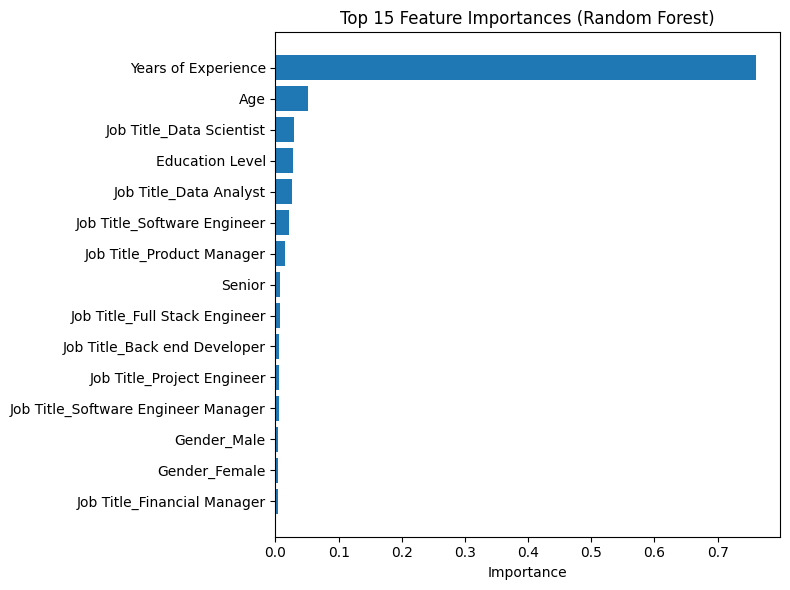

In [108]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"][::-1],
         top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.savefig("plots/feature_importance_rf_final.png", dpi=300, bbox_inches="tight")
plt.show()

#### Interpretation of Feature Importance (Deployed Model)

The feature importance analysis reveals that Years of Experience is the dominant predictor of salary in the deployed Random Forest model, contributing significantly more than any other feature. This indicates that salary variation within the dataset is primarily structured around accumulated professional experience.

While variables such as Age, Education Level, and specific Job Titles provide additional predictive value, their relative contributions are substantially smaller. This suggests that categorical distinctions and qualifications refine salary estimation but do not outweigh the fundamental influence of experience.

The observed importance distribution aligns with real-world compensation structures, where career progression and accumulated expertise are central determinants of earning potential. The model effectively captures this hierarchical relationship, reinforcing both its predictive validity and practical interpretability.

In [100]:
df.duplicated().sum()

np.int64(0)